In [1]:
import pandas as pd
import numpy as np
import os
from analysis_utils import *
import pickle
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import matplotlib.gridspec as gs

from plotting_utils import add_scale_bar, save_current_fig

import matplotlib.pyplot as plt
%matplotlib widget 

In [15]:
def plot_example_supralinear_analysis(cell_data, fig, gs, isi_val=25, row=0):
    # 1. Get the FULL unitary from 300ms trace (the gold standard for a single pulse)
    raw_300 = cell_data[cell_data['ISI'] == 300].iloc[0]['Gabazine_Trace']
    unitary_pulse = align_to_baseline(raw_300)
    
    # 2. Define THREE pulses for the expected trace (0ms, ISI ms, 2*ISI ms)
    stim_times = [0, isi_val, isi_val * 2]
    
    # 3. Generate Expected Compound EPSP
    # This sums the unitary 3 times at the specified intervals
    expected_full = create_expected_EPSP(unitary_pulse, stim_times)
    
    # 4. CRITICAL ALIGNMENT: 
    # Your helper function adds a 10ms (200 sample) baseline padding. 
    # We must strip this to align with the 'Measured' start point.
    offset_samples = int(10 * 20000 / 1000)
    
    # 5. Get Measured Trace
    isi_df = cell_data[(cell_data['ISI'] == isi_val) & (cell_data["Pathway"] == 'Perforant')]
    measured_trace = align_to_baseline(isi_df.iloc[0]['Gabazine_Trace'])
    
    # Match lengths exactly so the 'Difference' calculation doesn't error
    expected_aligned = expected_full[offset_samples : offset_samples + len(measured_trace)]
    if len(expected_aligned) < len(measured_trace):
        expected_aligned = np.pad(expected_aligned, (0, len(measured_trace) - len(expected_aligned)))

    time_axis = np.arange(0, len(measured_trace)) * 0.05

    # --- PLOTTING ---
    # Left: The 'Unit' used to build the model
    ax1 = fig.add_subplot(gs[row, 0:2])
    ax1.plot(time_axis[:2000], unitary_pulse[:2000], color='black', linewidth=1.5)
    ax1.set_title("Unitary Pulse", fontsize=10)

    # Middle: Comparison of Linear Model vs. Biological Data
    ax2 = fig.add_subplot(gs[row, 2:6])
    ax2.plot(time_axis, expected_aligned, label='Linear Summation', alpha=0.8, color='steelblue', linewidth=2)
    ax2.plot(time_axis, measured_trace, color='firebrick', label='Measured Data', alpha=0.7)
    ax2.set_title(f"ISI {isi_val}ms: Model vs. Data", fontsize=12)
    ax2.legend(loc='lower right', frameon=False, fontsize='small')

    # Right: The Residual (facilitation/depression)
    ax3 = fig.add_subplot(gs[row, 6:9])
    ax3.plot(time_axis, measured_trace - expected_aligned, color='blue', linewidth=1.5)
    ax3.set_title("Supralinear Component", fontsize=10)

    # Presentation Clean-up
    for ax in [ax1, ax2, ax3]:
        for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
        # Optional: uncomment to remove all axes for a "clean" look
        ax.axis('off')

def align_to_baseline(trace):
    baseline_samples = 1
    if trace is not None and len(trace) > baseline_samples:
        baseline = np.mean(trace[:baseline_samples])
        return trace - baseline
    return trace

In [5]:
file_path = '/Users/samgritz/Desktop/Rutgers/Milstein_Lab/Code/Rutgers-Neuroscience-PhD/GNB1_Paper_Analysis/paper_data/E_I_data/E_I_traces_for_plotting.pkl'

with open(file_path, 'rb') as file:
    # Load the object from the file
    df = pickle.load(file)

In [45]:
example_ISI_cell = df[df['Cell_ID'] == '20240905_c3'] 

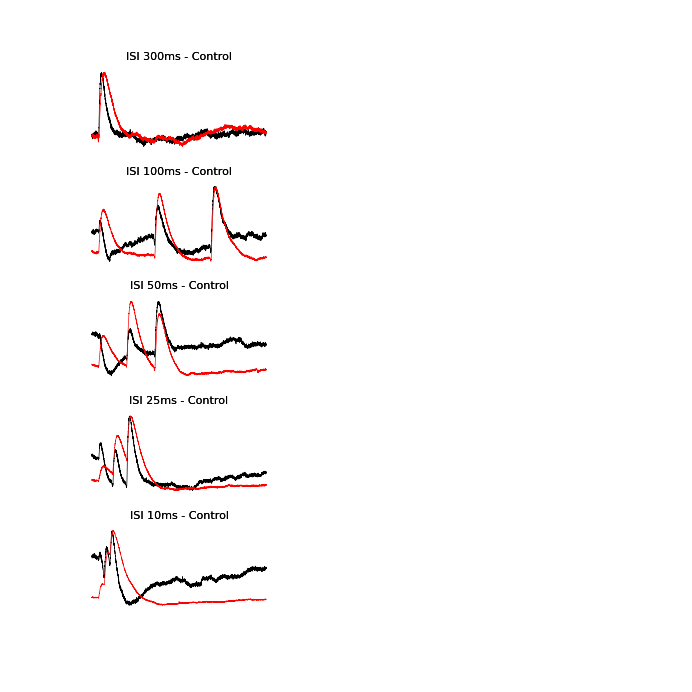

In [46]:
ISI_traces_Control = {300:[], 100:[], 50:[], 25:[], 10:[]} 
ISI_traces_Gabazine = {300:[], 100:[], 50:[], 25:[], 10:[]} 
ISI_list = [300, 100, 50, 25, 10]

for idx, row in example_ISI_cell.iterrows():
    for ISI in ISI_list:
        if (row['ISI'] == ISI) & (row['Pathway'] == 'Perforant'):
            current_trace_control = row['Control_Trace']
            ISI_traces_Control[ISI].append(current_trace_control)

            current_trace_gabazine = row['Gabazine_Trace']
            ISI_traces_Gabazine[ISI].append(current_trace_gabazine)

import matplotlib.gridspec as gridspec

cm_to_inch = 1 / 2.54
fig_width, fig_height = 17.6 * cm_to_inch, 17.6 * cm_to_inch
fig = plt.figure(figsize=(fig_width, fig_height))

# Outer grid: one row per ISI
outer_gs = GridSpec(nrows=5, ncols=1, left=0.12, right=0.95, top=0.90, bottom=0.12,
                    wspace=0.45, hspace=0.40)

for row_idx, ISI_time in enumerate(ISI_list):
    current_trace_control = ISI_traces_Control[ISI_time][0]
    current_trace_time = np.arange(0, len(current_trace_control) * 0.05, 0.05)
    current_trace_gabazine = ISI_traces_Gabazine[ISI_time][0]

    # Create a nested 1x2 grid inside this row
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer_gs[row_idx],
        wspace=0.4, width_ratios=[1, 1.5]
    )

    # Left panel (e.g., control trace)
    ax_left = fig.add_subplot(inner_gs[0, 0])
    ax_left.plot(current_trace_time, current_trace_control, color='black', linewidth=0.5)
    ax_left.set_title(f'ISI {ISI_time}ms - Control', fontsize=8)
    ax_left.axis('off')

    ax_left = fig.add_subplot(inner_gs[0, 0])
    ax_left.plot(current_trace_time, current_trace_gabazine, color='red', linewidth=0.5)
    ax_left.set_title(f'ISI {ISI_time}ms - Control', fontsize=8)
    ax_left.axis('off')


plt.show()

# plt.savefig('ISI_Control_Stim_Example.svg', format='svg', bbox_inches='tight')


### Plotting Theta Burst Examples

In [10]:
import pickle
import numpy as np


example_traces_path = '/Users/samgritz/Desktop/Rutgers/Milstein_Lab/Code/Rutgers-Neuroscience-PhD/Biophysical_model_sims/GNB1_Experimental_Data/Figure6_Example_Traces.pkl'
with open(example_traces_path, 'rb') as f:
            example_traces = pickle.load(f)

# WT_target_trace = example_traces['WT']['Both']
# WT_target_trace_time = np.arange(0, len(WT_target_trace)*0.05, 0.05)

# GNB1_target_trace = example_traces['GNB1']['Both']
# GNB1_target_trace_time = np.arange(0, len(GNB1_target_trace)*0.05, 0.05)

In [11]:
example_traces['WT']

{'Perforant': array([0.19759366, 0.16474897, 0.16474897, ..., 1.83982813, 1.87267282,
        1.77413875]),
 'Schaffer': array([-0.17801823, -0.17801823, -0.21086292, ..., -0.17801823,
        -0.11232884, -0.11232884]),
 'Both': array([-0.10628542, -0.20481949, -0.20481949, ...,  7.7764395 ,
         7.7764395 ,  7.71075013])}

In [12]:
WT_target_trace = example_traces['WT']['Both']
WT_target_trace_time = np.arange(0, len(WT_target_trace)*0.05, 0.05)

GNB1_target_trace = example_traces['GNB1']['Both']
GNB1_target_trace_time = np.arange(0, len(GNB1_target_trace)*0.05, 0.05)

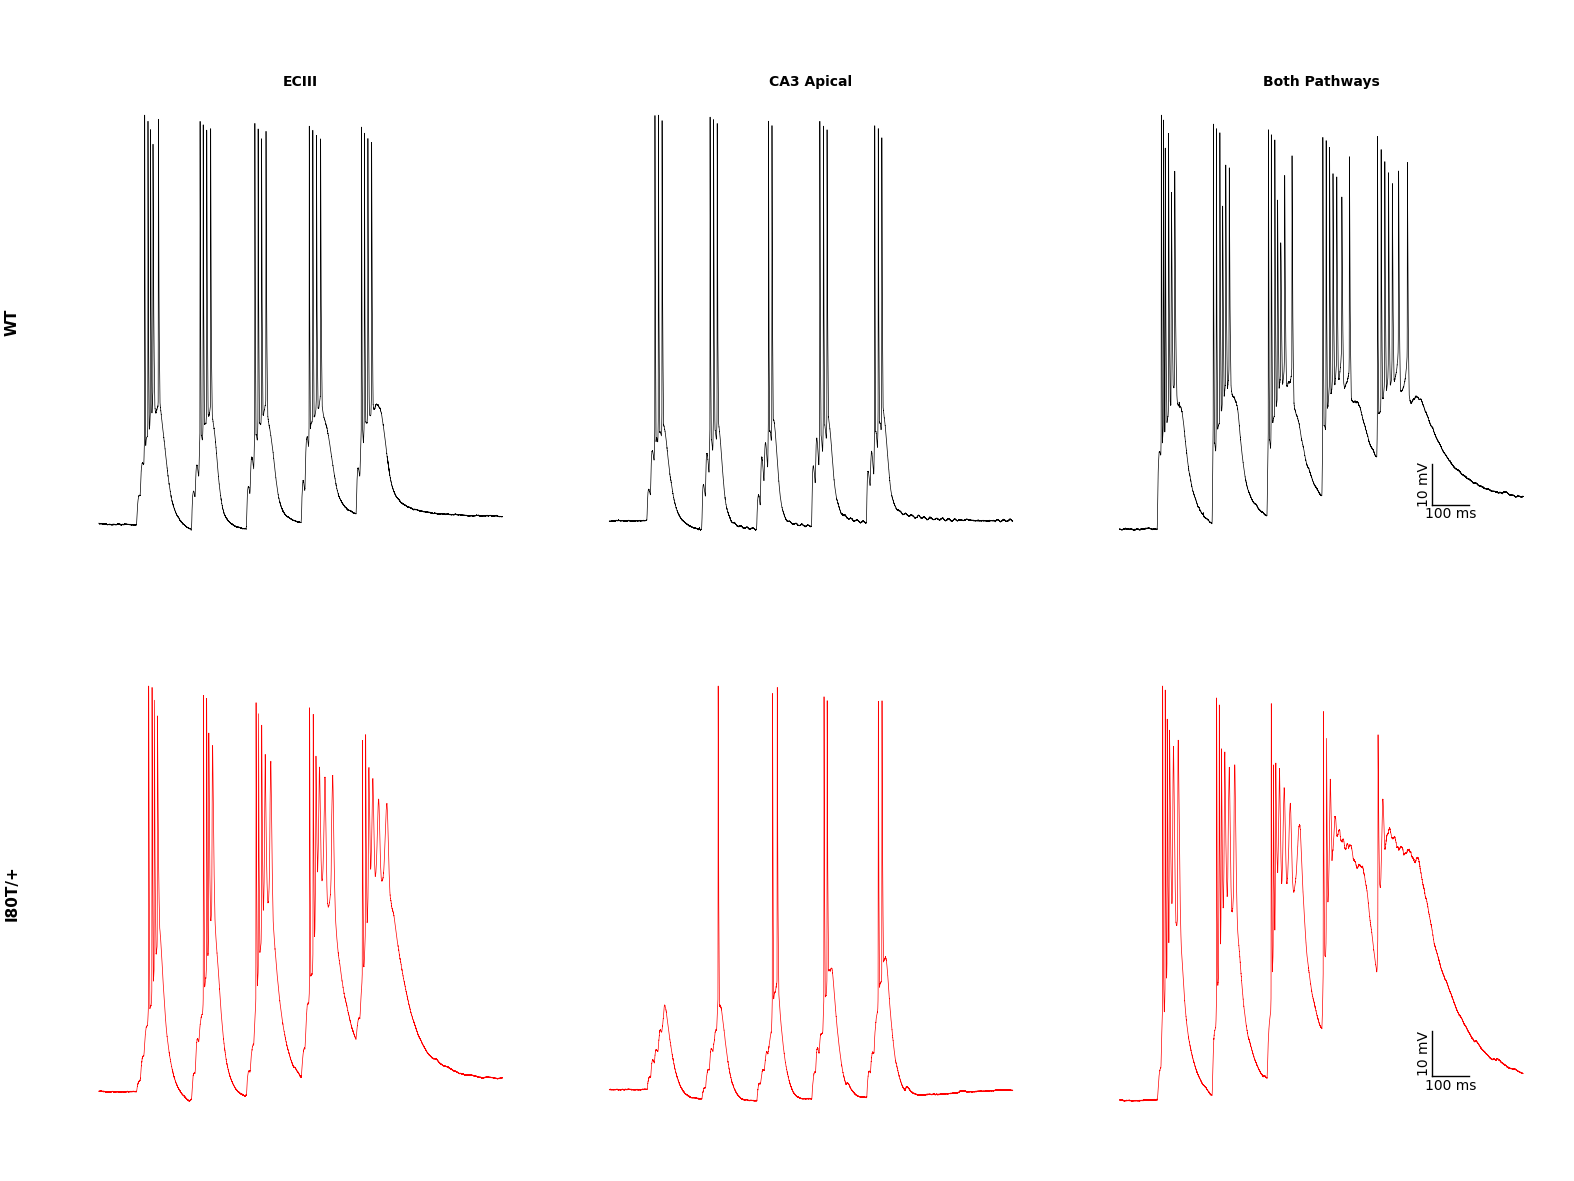

In [13]:
import matplotlib.gridspec as gridspec

cm_to_inch = 1 / 2.54
fig_width, fig_height = 40 * cm_to_inch, 30 * cm_to_inch
fig = plt.figure(figsize=(fig_width, fig_height))
time = np.arange(0, len(example_traces['WT']['Perforant']) * 0.05, 0.05)

# Outer grid: 2 rows (WT, GNB1) x 3 cols (Perforant, Schaffer, Both)
outer_gs = GridSpec(nrows=2, ncols=3, left=0.05, right=0.98, top=0.92, bottom=0.05,
                    wspace=0.15, hspace=0.25)

genotypes = ['WT', 'GNB1']
genotype_labels= ['WT', 'I80T/+']
pathways = ['Perforant', 'Schaffer', 'Both']
pathway_labels = ['ECIII', 'CA3 Apical', 'Both Pathways']

for row_idx, geno in enumerate(genotypes):
    for col_idx, pathway in enumerate(pathways):
        ax = fig.add_subplot(outer_gs[row_idx, col_idx])
        
        trace = example_traces[geno][pathway]
        trace_time = np.arange(0, len(trace) * 0.05, 0.05)
        
        if geno == 'WT':
                ax.plot(trace_time, trace, color='black', linewidth=0.5)
        else:
                ax.plot(trace_time, trace, color='red', linewidth=0.5)
        
        # Title only on top row
        if row_idx == 0:
            ax.set_title(pathway_labels[col_idx], fontsize=10, fontweight='bold')
        
        # Genotype label on left column
        if col_idx == 0:
            ax.annotate(genotype_labels[row_idx], xy=(-0.15, 0.5), xycoords='axes fraction',
                        fontsize=11, fontweight='bold', ha='center', va='center', rotation=90)
        
        # Scale bar on the last panel of each row
        if col_idx == 2:
            add_scale_bar(ax, x_scale_ms=100, y_scale_mv=10, x_pos=0.75, y_pos=0.10)
        
        # Remove all axes
        ax.axis('off')

# fig.savefig('example_Theta_Burst_traces.svg', format='svg', bbox_inches='tight')
plt.show()


# Generate Measured - Expected and Supralinear traces

In [14]:
# selected_cells_fig6 = {
#     'WT': {'file': '03252025_c2_processed_data.pkl', 'rows': {'Perforant': 10, 'Schaffer': 11, 'Both': 12}, 'apply_noise_removal': True},
#     'GNB1': {'file': '06062025_c1_processed_data.pkl', 'rows': {'Perforant': 7, 'Schaffer': 8, 'Both': 9}, 'apply_noise_removal': True}
# }

In [15]:
all_EPSP_traces_path = '/Users/samgritz/Desktop/Rutgers/Milstein_Lab/Code/Rutgers-Neuroscience-PhD/GNB1_Paper_Analysis/paper_data/E_I_data/E_I_traces_for_plotting.pkl' 
with open(all_EPSP_traces_path, 'rb') as f:
            all_EPSP_traces = pickle.load(f)

example_E_I_cell = all_EPSP_traces[all_EPSP_traces['Cell_ID'] == '20250514_c2']
example_E_I_cell

,Cell_ID,Genotype,Sex,ISI,Channel,Pathway,Control_Trace,Gabazine_Trace,Gabazine + ETX_Trace,estimated_inhibition_Trace,Expected_EPSP_Trace,Gabazine + ML297_Trace,Gabazine + Baclofen_Trace,_Trace,control_Trace,Gabazine + MCPG_Trace,gabazine_Trace,Gabazine + Baclofen _Trace
0,20250514_c2,GNB1,Female,300,channel_1,Perforant,"[0.005199253156575878, -0.005748976903025967, ...","[-0.017392354288877716, -0.006444124161996949,...","[0.033950461477942895, 0.0448986914852109, 0.0...","[-0.022591607445453594, -0.0006951472589709819...","[-0.017392354288877716, -0.006444124161996949,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20250514_c2,GNB1,Female,300,channel_2,Schaffer,"[-0.03906361642007047, -0.006218926443082751, ...","[0.00594522064047472, -0.02689946949348136, 0....","[0.019577425997084674, 0.019577425967170825, -...","[0.04500883706054519, -0.020680543050398608, 0...","[0.00594522064047472, -0.02689946949348136, 0....",NaN,NaN,NaN,NaN,NaN,NaN,NaN


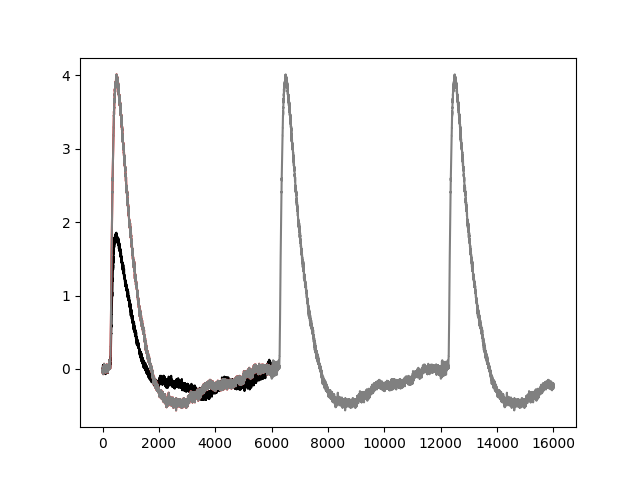

In [16]:
example_E_I_cell_ISI_300_Gabazine = example_E_I_cell[(example_E_I_cell['Pathway'] == 'Perforant')]['Gabazine_Trace'][0]
example_E_I_cell_ISI_300_Control = example_E_I_cell[(example_E_I_cell['Pathway'] == 'Perforant')]['Control_Trace'][0]

example_E_I_cell_ISI_300_expected = example_E_I_cell[(example_E_I_cell['Pathway'] == 'Perforant')]['Expected_EPSP_Trace'][0]

plt.figure()

plt.plot(example_E_I_cell_ISI_300_Control, color = 'black')
plt.plot(example_E_I_cell_ISI_300_Gabazine, color = 'red') 
plt.plot(example_E_I_cell_ISI_300_expected, color = 'grey')

In [17]:
# The first burst in the expected trace is larger than the rest. This is because with start = stim_index - baseline_len, 
# the template's baseline (10ms before the EPSP onset) gets placed before the stim time. For the first burst, the stim times are absolute (like 500, 510, 520ms). With start = stim_index - baseline_len:


# stim=500ms → stim_index=10000, start=10000-200=9800. The full unitary template (baseline + EPSP) is placed starting at 9800.

In [26]:
All_raw_data_path = '/Users/samgritz/Library/CloudStorage/Box-Box/Milstein-Shared/Sam/GNB1_Paper_Data/Electrophysiology_Experiments/All_Combined_Data'

In [27]:
data_files = [f for f in os.listdir(All_raw_data_path) if f.endswith('.pkl')]

In [32]:
# for file in data_files:
#     df = pd.read_pickle(os.path.join(All_raw_data_path, file))
#     for i in range(len(df)):
#         row = df.iloc[i]
#         desc = row.get('experiment_description', '')
#         if 'Theta Stim' in desc:
#             trace = None
#             if 'intermediate_traces' in row:
#                 trace = row['intermediate_traces'].get('offset_trace')
#                 print(trace) 

[-0.00944126 -0.00944126  0.08909281 ...  0.15478218  0.15478218
  0.18762687]
[-0.13497675 -0.20066613 -0.16782144 ... -0.10213206 -0.13497675
 -0.16782144]
[0.11147817 0.04578879 0.11147817 ... 1.32673168 1.35957637 1.35957637]
[0.83683293 0.83683293 0.77114355 ... 1.78932892 1.75648423 1.72363954]
[-6.00312902 -6.00312902 -6.00312902 ...  0.5986542   0.56580951
  0.66434358]
[-6.16960672 -6.16960672 -6.16960672 ...  0.62924454  0.69493392
  0.69493392]
[-6.2800993  -6.2800993  -6.2800993  ...  0.51875202  0.5844414
  0.42021795]
[-6.08210554 -6.08210554 -6.08210554 ...  0.84812455  0.78243517
  0.84812455]
[-4.76800414 -4.76800414 -4.76800414 ... -0.46534954 -0.39966016
 -0.43250485]
[-4.4134457  -4.4134457  -4.4134457  ...  0.02058765  0.08627703
  0.05343234]
[-4.74026537 -4.74026537 -4.74026537 ... -0.01062974 -0.01062974
 -0.01062974]
[-4.54094786 -4.54094786 -4.54094786 ...  0.22153246  0.22153246
  0.22153246]
[-3.79787653 -3.79787653 -3.79787653 ...  1.1945166   1.22736129
  

In [18]:
all_plateau_traces_path = '/Users/samgritz/Desktop/Rutgers/Milstein_Lab/Code/Rutgers-Neuroscience-PhD/GNB1_Paper_Analysis/paper_data/Plateau_data/All_Plateau_Traces.pkl' 
with open(all_plateau_traces_path, 'rb') as f:
            all_plateau_traces = pickle.load(f)

WT_plateau_example_both_pathway_stim = all_plateau_traces['Before_ML297']['20250325_c2']['traces']['Both']
# GNB1_plateau_example_both_pathway_stim = all_plateau_traces['Before_ETX']['20250606_c1']['traces']['Both']

In [19]:
all_supralinear_traces_path = '/Users/samgritz/Desktop/Rutgers/Milstein_Lab/Code/Rutgers-Neuroscience-PhD/GNB1_Paper_Analysis/paper_data/supralinearity/Supralinear_Traces_Plotting.pkl'
with open(all_supralinear_traces_path, 'rb') as f:
            all_supralinear_traces = pickle.load(f)

In [20]:
measured_both_supralinear_trace_WT = all_supralinear_traces['20250325_c2']['Both Pathways']['Measured']

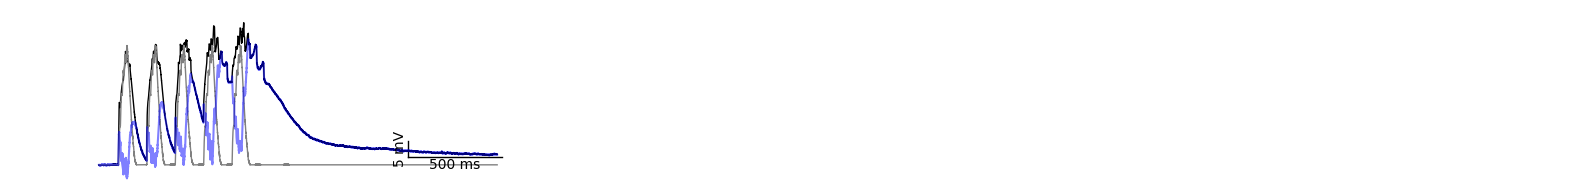

In [25]:
cm_to_inch = 1 / 2.54
fig_width, fig_height = 40 * cm_to_inch, 5 * cm_to_inch
fig = plt.figure(figsize=(fig_width, fig_height))
time = np.arange(0, len(measured_both_supralinear_trace_WT) * 0.05, 0.05)

# Outer grid: 2 rows (WT, GNB1) x 3 cols (Perforant, Schaffer, Both)
outer_gs = GridSpec(nrows=1, ncols=3, left=0.05, right=0.98, top=0.92, bottom=0.05,
                    wspace=0.15, hspace=0.25)

ax = fig.add_subplot(outer_gs[0, 0])

ax.plot(time, all_supralinear_traces['20250325_c2']['Both Pathways']['Measured'], color = 'black', linewidth = 1, label = 'Measure: No Inhibition')
ax.plot(time, all_supralinear_traces['20250325_c2']['Both Pathways']['Expected'], color = 'grey', linewidth = 1, label = 'Expected: Linear Summation')
add_scale_bar(ax, x_scale_ms=500, y_scale_mv=5, x_pos=0.75, y_pos=0.10)
ax.plot(time, all_supralinear_traces['20250325_c2']['Both Pathways']['Difference'], color = 'blue', alpha = 0.5, label = 'Supralinear Trace: Measured - Expected') 
ax.axis('off')
# ax.legend()

fig.savefig('example_Theta_Burst_Supralinear_Example.svg', format='svg', bbox_inches='tight')



In [22]:
# cm_to_inch = 1 / 2.54
# fig_width, fig_height = 17.6 * cm_to_inch, 17.6 * cm_to_inch
# fig = plt.figure(figsize=(fig_width, fig_height))
# gs = GridSpec(nrows=2, ncols=3, left=0.12, right=0.95, top=0.90, bottom=0.12,
#               wspace=0.45, hspace=0.40)

# # (cell_data, fig, gs, isi_val=100, row=0)
# plot_example_supralinear_analysis(df[df['Cell_ID'] == '20240326_c2'], fig, gs, isi_val=300, row=1)
# # plot_example_supralinear_analysis(df[df['Cell_ID'] == '20240905_c3'], fig, gs, isi_val=100, row=1)
# # plot_example_supralinear_analysis(df[df['Cell_ID'] == '20240905_c3'], fig, gs, isi_val=50, row=2)
# # plot_example_supralinear_analysis(df[df['Cell_ID'] == '20240905_c3'], fig, gs, isi_val=25, row=3)
# # plot_example_supralinear_analysis(df[df['Cell_ID'] == '20240905_c3'], fig, gs, isi_val=10, row=4)


# # 4. Show the result
# plt.show()


# # save_current_fig('Supralinear_E_I_Analysis')

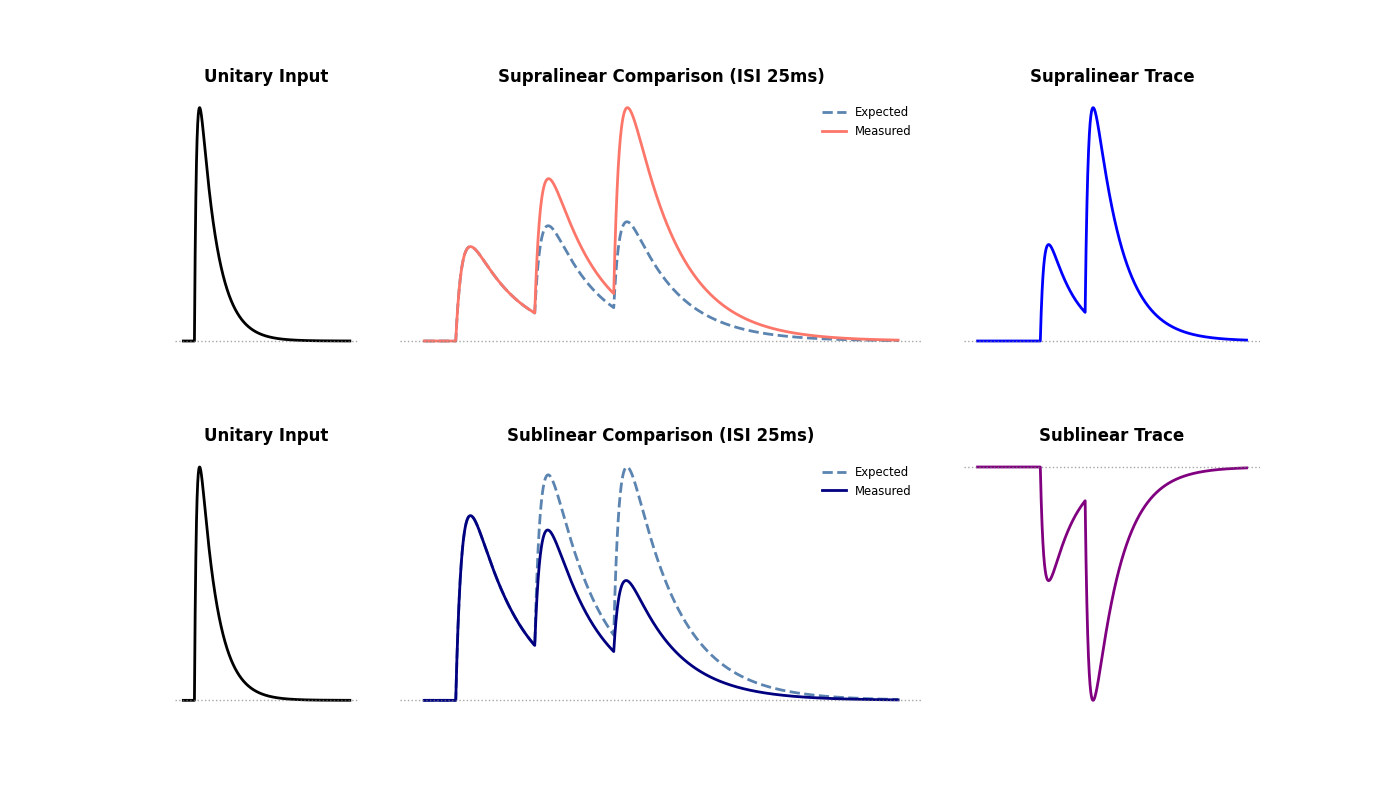

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def create_expected_EPSP(unitary_EPSP, stim_times):
    """Sums unitary EPSPs linearly at stim_times with a 10ms baseline."""
    baseline_len = int(10 * 20000 / 1000)
    unitary_len = len(unitary_EPSP)
    # 400ms window ensures the trace doesn't "cliff" at the end
    total_len = int(400 * 20000 / 1000) 
    compound_EPSP = np.zeros(total_len)

    for stim in stim_times:
        stim_index = int(stim * 20000 / 1000)
        start = baseline_len + stim_index
        end = start + unitary_len
        
        if start < total_len:
            if end <= total_len:
                compound_EPSP[start:end] += unitary_EPSP
            else:
                overlap_len = total_len - start
                compound_EPSP[start:] += unitary_EPSP[:overlap_len]
    return compound_EPSP

# --- DATA GENERATION ---
fs = 20000
t_unitary = np.arange(0, 0.15, 1/fs)
tau_rise, tau_decay = 0.002, 0.015
unitary_trace = (np.exp(-t_unitary/tau_decay) - np.exp(-t_unitary/tau_rise))
unitary_trace /= np.max(unitary_trace)

isi = 25
stim_times = [0, isi, isi * 2]

# 1. Base Linear Model (Expected)
expected_trace = create_expected_EPSP(unitary_trace, stim_times)

# 2. Supralinear Facilitation (Weights: 1.0, 1.5, 2.1)
measured_supra = (create_expected_EPSP(unitary_trace, [0]) + 
                  create_expected_EPSP(unitary_trace * 1.5, [isi]) + 
                  create_expected_EPSP(unitary_trace * 2.1, [isi * 2]))

# 3. Sublinear Depression (Weights: 1.0, 0.7, 0.45)
measured_sub = (create_expected_EPSP(unitary_trace, [0]) + 
                create_expected_EPSP(unitary_trace * 0.7, [isi]) + 
                create_expected_EPSP(unitary_trace * 0.45, [isi * 2]))

# --- PRESENTATION PLOTTING ---
fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 10, hspace=0.4, wspace=0.6)
time_ms = np.arange(len(expected_trace)) * (1000/fs)
plot_range = (time_ms >= 0) & (time_ms <= 150)

def format_presentation_ax(ax, title):
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.axhline(0, color='gray', linestyle=':', lw=1, alpha=0.7) # Dotted zero line
    ax.axis('off')

# Unitary visualization (shifted 10ms to match the compound baseline)
u_plot = np.zeros_like(expected_trace)
u_plot[int(10*fs/1000):int(10*fs/1000)+len(unitary_trace)] = unitary_trace

# --- ROW 0: SUPRALINEAR (FACILITATION) ---
ax_u0 = fig.add_subplot(gs[0, 0:2])
ax_u0.plot(time_ms[plot_range], u_plot[plot_range], color='black', lw=2)
format_presentation_ax(ax_u0, "Unitary Input")

ax_c0 = fig.add_subplot(gs[0, 2:7])
ax_c0.plot(time_ms[plot_range], expected_trace[plot_range], color='#5B84B1', lw=2, ls='--', label='Expected')
ax_c0.plot(time_ms[plot_range], measured_supra[plot_range], color='#FC766A', lw=2, label='Measured')
ax_c0.legend(frameon=False, loc='upper right', fontsize='small')
format_presentation_ax(ax_c0, f"Supralinear Comparison (ISI {isi}ms)")

ax_d0 = fig.add_subplot(gs[0, 7:10])
diff_supra = measured_supra - expected_trace
ax_d0.plot(time_ms[plot_range], diff_supra[plot_range], color='blue', lw=2)
format_presentation_ax(ax_d0, "Supralinear Trace")

# --- ROW 1: SUBLINEAR (DEPRESSION) ---
ax_u1 = fig.add_subplot(gs[1, 0:2])
ax_u1.plot(time_ms[plot_range], u_plot[plot_range], color='black', lw=2)
format_presentation_ax(ax_u1, "Unitary Input")

ax_c1 = fig.add_subplot(gs[1, 2:7])
ax_c1.plot(time_ms[plot_range], expected_trace[plot_range], color='#5B84B1', lw=2, ls='--', label='Expected')
ax_c1.plot(time_ms[plot_range], measured_sub[plot_range], color='navy', lw=2, label='Measured')
ax_c1.legend(frameon=False, loc='upper right', fontsize='small')
format_presentation_ax(ax_c1, f"Sublinear Comparison (ISI {isi}ms)")

ax_d1 = fig.add_subplot(gs[1, 7:10])
diff_sub = measured_sub - expected_trace
ax_d1.plot(time_ms[plot_range], diff_sub[plot_range], color='purple', lw=2)
format_presentation_ax(ax_d1, "Sublinear Trace")



plt.show()

plt.savefig("Supralinear_Example.svg")